Class Distribution:
No-show
No     88208
Yes    22319
Name: count, dtype: int64


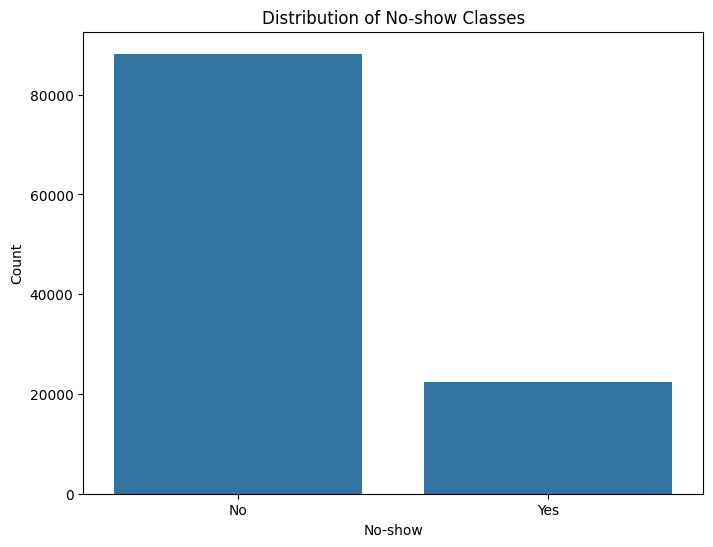


Class distribution before balancing:
No-show
0    88208
1    22319
Name: count, dtype: int64

Class distribution after balancing:
No-show
0    88208
1    88208
Name: count, dtype: int64


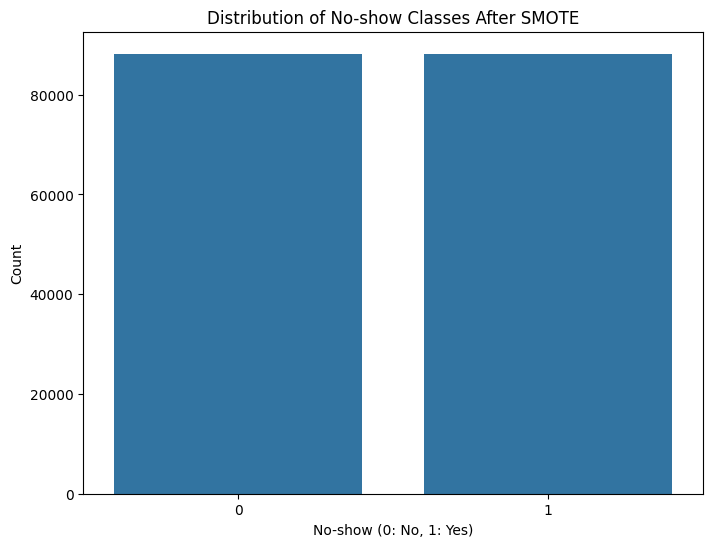


Training set shape: (112905, 8) (112905,)
Validation set shape: (28227, 8) (28227,)
Testing set shape: (35284, 8) (35284,)

Class distribution in training set:
No-show
1    56453
0    56452
Name: count, dtype: int64

Class distribution in validation set:
No-show
0    14114
1    14113
Name: count, dtype: int64

Class distribution in testing set:
No-show
0    17642
1    17642
Name: count, dtype: int64
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Parameter terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Akurasi pada Training set: 0.8183871396306629
Akurasi pada Validation set: 0.7483614978566621
Akurasi pada Testing set: 0.7451536107017345


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv('MedicalAppointmentNoShows_Dataset.csv')

# 1. Feature Engineering
# Konversi kolom tanggal ke datetime dengan format yang sesuai
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], utc=True)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], utc=True)

# Pastikan AppointmentDay hanya mengambil tanggal (karena waktu sering 00:00:00)
df['AppointmentDay'] = df['AppointmentDay'].dt.normalize()  # Set waktu ke 00:00:00

# Hitung waktu tunggu (dalam hari)
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Tangani nilai negatif (jika ada, set ke 0)
df['WaitingDays'] = df['WaitingDays'].clip(lower=0)

# Normalisasi Age dan WaitingDays
scaler = MinMaxScaler()
df['Age_normalized'] = scaler.fit_transform(df[['Age']])
df['WaitingDays_normalized'] = scaler.fit_transform(df[['WaitingDays']])

# Pilih fitur
X = df[['Age_normalized', 'WaitingDays_normalized', 'Scholarship', 'Hipertension', 
        'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']]
y = df['No-show'].map({'No': 0, 'Yes': 1})

# Distribusi kelas awal
print("Class Distribution:")
print(df['No-show'].value_counts())

# Visualisasi distribusi kelas
plt.figure(figsize=(8, 6))
sns.countplot(x='No-show', data=df)
plt.title('Distribution of No-show Classes')
plt.xlabel('No-show')
plt.ylabel('Count')
plt.show()

# 2. Balancing dengan SMOTE
print("\nClass distribution before balancing:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nClass distribution after balancing:")
print(pd.Series(y_balanced).value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x=y_balanced)
plt.title('Distribution of No-show Classes After SMOTE')
plt.xlabel('No-show (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# 3. Data Splitting
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_balanced
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_temp
)

# Verify the split
print("\nTraining set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Testing set shape:", X_test.shape, y_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in validation set:")
print(pd.Series(y_val).value_counts())
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts())

# 4. Latih model Random Forest dengan Hyperparameter Tuning
rf = RandomForestClassifier(random_state=42)

# Definisikan parameter grid untuk tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Lakukan GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Dapatkan model terbaik
best_model = grid_search.best_estimator_
print("\nParameter terbaik:", grid_search.best_params_)

# Prediksi dan hitung akurasi
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)
y_test_pred = best_model.predict(X_test)

# Hitung akurasi
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nAkurasi pada Training set:", train_accuracy)
print("Akurasi pada Validation set:", val_accuracy)
print("Akurasi pada Testing set:", test_accuracy)